# Insurance Premium Prediction Using Machine Learning

## Project Overview
This project predicts insurance premium charges based on customer information such as age, BMI, smoking habits, gender, and region using Machine Learning regression algorithms.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Load Dataset

In [2]:
df = pd.read_csv('../data/insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Dataset Information

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Check Missing Values

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Exploratory Data Analysis (EDA)

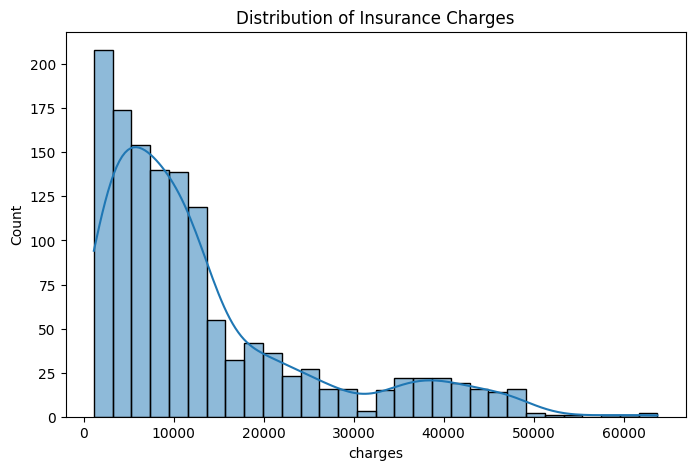

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['charges'],
    kde=True
)

plt.title("Distribution of Insurance Charges")

plt.show()

### Observation
The distribution of insurance charges is positively skewed (right-skewed). Most customers have lower insurance charges, while a smaller number of customers have very high charges. This indicates the presence of outliers and variability in premium costs.

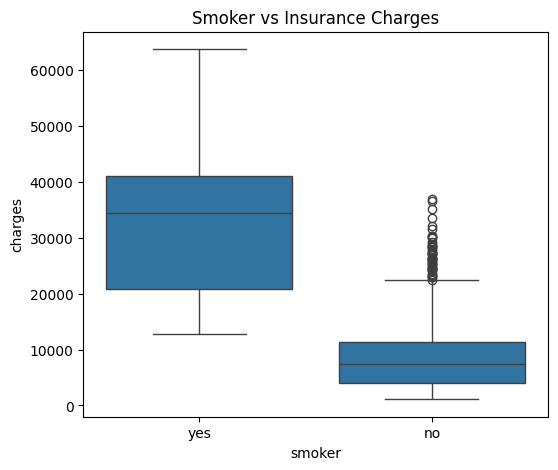

In [7]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title("Smoker vs Insurance Charges")

plt.show()

### Observation
Smokers have significantly higher insurance charges compared to non-smokers. The median insurance cost for smokers is much higher, indicating that smoking is a major factor affecting insurance premiums.

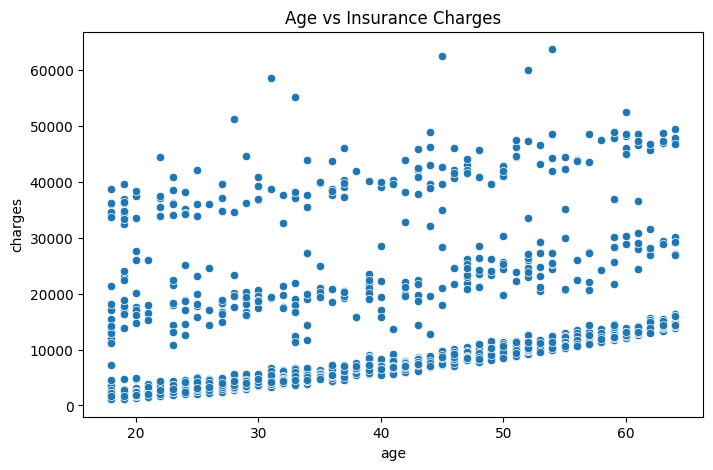

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    data=df
)

plt.title("Age vs Insurance Charges")

plt.show()

### Observation
The scatter plot shows a positive relationship between age and insurance charges. As age increases, insurance charges generally tend to increase. Older individuals are likely to have higher medical risks, resulting in higher insurance premiums.

In [9]:
temp = df.copy()

encoder = LabelEncoder()

temp['sex'] = encoder.fit_transform(temp['sex'])

temp['smoker'] = encoder.fit_transform(temp['smoker'])

temp['region'] = encoder.fit_transform(temp['region'])

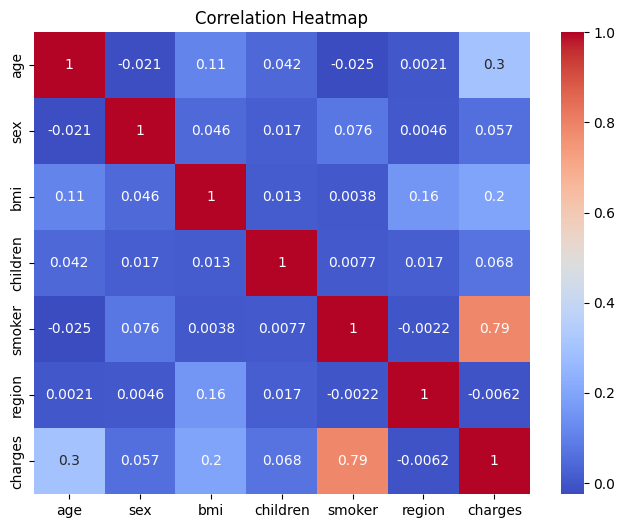

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing

In [11]:
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])

df['smoker'] = encoder.fit_transform(df['smoker'])

df['region'] = encoder.fit_transform(df['region'])

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [13]:
X = df.drop(
    'charges',
    axis=1
)

y = df['charges']

In [14]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


In [15]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

# Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [17]:
print(X_train.shape)

print(X_test.shape)

(1070, 6)
(268, 6)


# Model Training

In [18]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
pred = model.predict(X_test)

# Model Evaluation

In [20]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        pred
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 4186.508898366434
MSE: 33635210.431178406
R2 Score: 0.7833463107364539


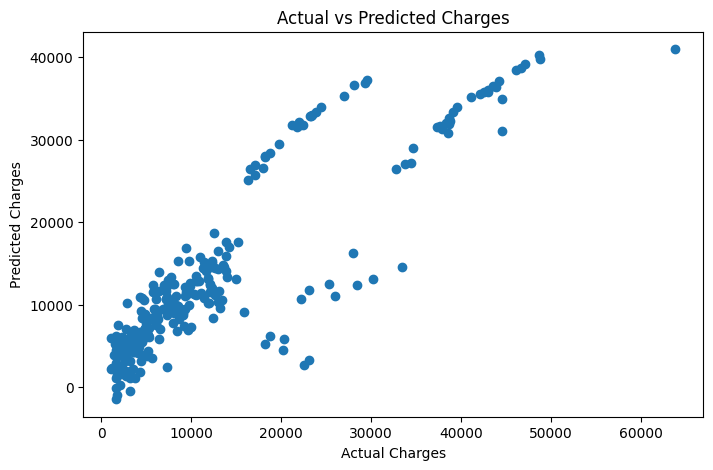

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

# Save Trained Model

In [22]:
joblib.dump(
    model,
    '../models/model.pkl'
)

['../models/model.pkl']

# Conclusion

The project successfully predicts insurance premium charges using Machine Learning techniques. Linear Regression was used to train the model, and the model achieved good prediction accuracy based on evaluation metrics such as MAE, MSE, and R² Score.